## Sección 0 – Setup
- Cargar df_entrenamiento_v1.csv
- Eliminar registros del año 2012
- Definir features finales y variable objetivo (target)

In [2]:
import pandas as pd
from pathlib import Path

# Cargar dataset congelado
freeze_folder = Path('..') / 'freeze'
csv_files = sorted(freeze_folder.glob('df_entrenamiento_v1_*.csv'))
assert csv_files, 'No se encontró archivo df_entrenamiento_v1_*.csv en freeze/'
data_path = csv_files[-1]  # Usar el más reciente
df = pd.read_csv(data_path)
print(f'Dataset cargado: {data_path}')
print(f'Dimensiones iniciales: {df.shape[0]} filas x {df.shape[1]} columnas')

# Convertir fecha y eliminar 2012
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['date'].dt.year
    df = df[df['year'] != 2012].copy()
    print(f'Dimensiones tras eliminar 2012: {df.shape[0]} filas')

# Definir features finales y target
target = 'pred_evento'
features = [col for col in df.columns if col not in ['date', 'year', target]]
print('Features finales:', features)
print('Target:', target)

Dataset cargado: ..\freeze\df_entrenamiento_v1_20251228_200900.csv
Dimensiones iniciales: 16161 filas x 18 columnas
Dimensiones tras eliminar 2012: 16160 filas
Features finales: ['prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'delta_1', 'slope_7', 'slope_14', 'ratio14']
Target: pred_evento


In [3]:
if 'presion_de_casing_psi' in df.columns:
    df = df.drop(columns=['presion_de_casing_psi'])
    print('Columna presion_de_casing_psi eliminada.')
else:
    print('La columna presion_de_casing_psi no está presente en el DataFrame.')

Columna presion_de_casing_psi eliminada.


## Sección 1 – Variable binaria auxiliar para baseline
Se crea `target_binario`: 1 si pred_evento ∈ {1, 2}, 0 si pred_evento = 0.
La variable original `pred_evento` se mantiene intacta para experimentos multiclase.

La variable pred_evento se conservó como etiqueta multiclase original. Para la evaluación inicial del desempeño del modelo, se definió una variable binaria auxiliar orientada a la detección de eventos, sin modificar la etiqueta original, permitiendo posteriormente extender el análisis a una clasificación multiclase más detallada.

In [5]:
# Crear variable binaria auxiliar para baseline
# 1 si pred_evento ∈ {1, 2}, 0 si pred_evento = 0

df['target_binario'] = df['pred_evento'].apply(lambda x: 1 if x in [1, 2] else 0)
print(df['target_binario'].value_counts())

target_binario
0    12510
1     3650
Name: count, dtype: int64


## Sección 2 – Split temporal
Entrenamiento: 2018–2022
Test: 2023–2025

In [8]:
# Eliminar presion_de_casing_psi si existe
if 'presion_de_casing_psi' in df.columns:
    df = df.drop(columns=['presion_de_casing_psi'])
    print('Columna presion_de_casing_psi eliminada.')

# Definir target binario (baseline)
target = 'target_binario'

# Definir features finales (sin leakage)
exclude_cols = ['date', 'year', 'pred_evento', 'target_binario', 'name_']
features = [col for col in df.columns if col not in exclude_cols]

print('Número de features:', len(features))
print('Features finales:', features)
print('Target:', target)

# Split temporal para baseline binario
train_mask = df['year'].between(2018, 2022)
test_mask = df['year'].between(2023, 2025)

X_train = df.loc[train_mask, features]
y_train = df.loc[train_mask, target]

X_test = df.loc[test_mask, features]
y_test = df.loc[test_mask, target]

print(f'Train: {X_train.shape[0]} muestras, Test: {X_test.shape[0]} muestras')


Número de features: 15
Features finales: ['prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'delta_1', 'slope_7', 'slope_14', 'ratio14']
Target: target_binario
Train: 8117 muestras, Test: 5005 muestras


In [10]:
# Entrenamiento y evaluación XGBoost baseline (ejecutar al final)
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = XGBClassifier(tree_method='hist', use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

c:\Users\Vìctor\OneDrive\Desktop\ESP_Project\venv_esp\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:20:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion matrix:
[[3046  607]
 [ 463  889]]

Classification report:
              precision    recall  f1-score   support

           0      0.868     0.834     0.851      3653
           1      0.594     0.658     0.624      1352

    accuracy                          0.786      5005
   macro avg      0.731     0.746     0.737      5005
weighted avg      0.794     0.786     0.789      5005



## Diagnóstico de missingness y creación de indicadores
Estos datos provienen de pruebas válidas del OFM, realizadas varias veces por mes. El missingness puede ser estructural y relevante para la detección de anomalías.

In [14]:
# Diagnóstico de missingness y creación de indicadores de missingness
import numpy as np

# Diagnóstico: porcentaje de NaN por variable
missing_pct = df.isnull().mean() * 100
print('Porcentaje de NaN por variable:')
print(missing_pct.sort_values(ascending=False))

# Crear un nuevo DataFrame para los indicadores de missingness
df_miss = df.copy()

# Crear indicadores de missingness para variables con NaN SOLO en df_miss
variables_con_nan = missing_pct[missing_pct > 0].index.tolist()
for var in variables_con_nan:
    df_miss[f'{var}_is_missing'] = df_miss[var].isnull().astype(int)

print('Indicadores de missingness creados para:', variables_con_nan)
print('Ejemplo de columnas con indicadores:', [f'{var}_is_missing' for var in variables_con_nan][:5])

Porcentaje de NaN por variable:
temperatura_de_la_bomba_deg_f                    40.742574
presion_de_intake_psi                            32.252475
amperaje_bomba_amp                               17.871287
frecuencia_bomba_hz                              17.153465
salinidad_ppm_pu                                 14.480198
etapas_de_la_bomba                               12.500000
ratio14                                           3.972772
slope_14                                          1.132426
slope_7                                           0.563119
gravedad_api_del_petroleo                         0.402228
delta_1                                           0.278465
presion_de_tubing_psi                             0.235149
bsw_pct                                           0.030941
prueba_de_produccion_petróleo_a_24_horas_bbld     0.000000
prueba_de_producción_gas_a_24_horas_mcfd          0.000000
date                                              0.000000
pred_evento             

Indicadores de missingness usados (≥5%): ['salinidad_ppm_pu_is_missing', 'presion_de_intake_psi_is_missing', 'frecuencia_bomba_hz_is_missing', 'amperaje_bomba_amp_is_missing', 'temperatura_de_la_bomba_deg_f_is_missing', 'etapas_de_la_bomba_is_missing']
Número total de features con indicadores: 21


c:\Users\Vìctor\OneDrive\Desktop\ESP_Project\venv_esp\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:31:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion matrix (con indicadores):
[[3046  607]
 [ 463  889]]

Classification report (con indicadores):
              precision    recall  f1-score   support

           0      0.868     0.834     0.851      3653
           1      0.594     0.658     0.624      1352

    accuracy                          0.786      5005
   macro avg      0.731     0.746     0.737      5005
weighted avg      0.794     0.786     0.789      5005



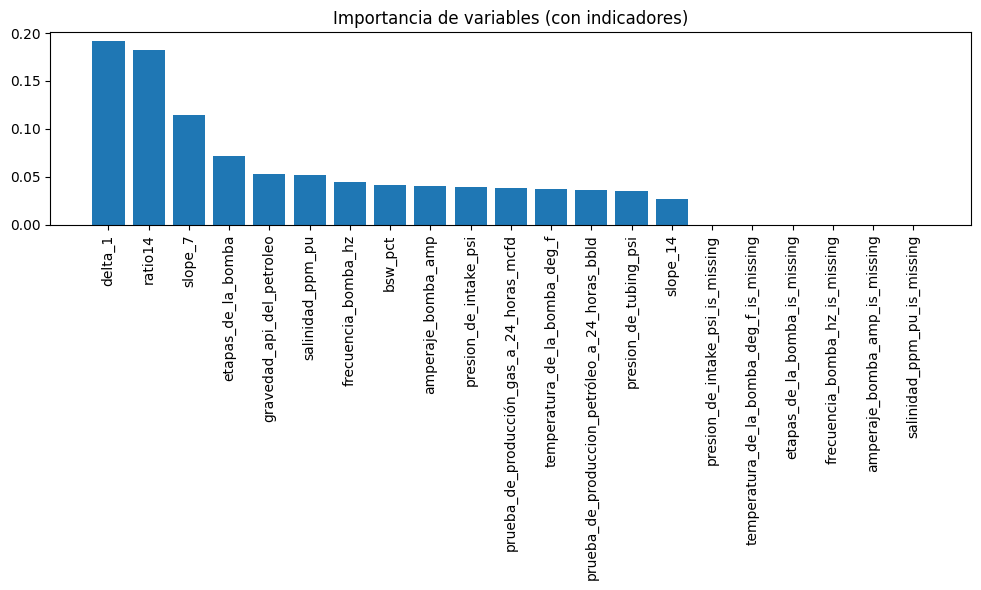

Métricas por año (con indicadores):

Año: 2023 (n=1692)
              precision    recall  f1-score   support

           0      0.851     0.865     0.858      1180
           1      0.677     0.650     0.663       512

    accuracy                          0.800      1692
   macro avg      0.764     0.758     0.761      1692
weighted avg      0.798     0.800     0.799      1692


Año: 2024 (n=1767)
              precision    recall  f1-score   support

           0      0.890     0.876     0.883      1360
           1      0.606     0.639     0.622       407

    accuracy                          0.821      1767
   macro avg      0.748     0.757     0.752      1767
weighted avg      0.825     0.821     0.823      1767


Año: 2025 (n=1546)
              precision    recall  f1-score   support

           0      0.859     0.749     0.800      1113
           1      0.515     0.684     0.587       433

    accuracy                          0.731      1546
   macro avg      0.687     0.71

In [15]:
# --- Filtrar indicadores de missingness por umbral (≥5%) ---
umbral = 5.0
indicadores_5pct = [f'{var}_is_missing' for var in variables_con_nan if missing_pct[var] >= umbral]
print(f'Indicadores de missingness usados (≥5%): {indicadores_5pct}')

# --- Actualizar lista de features para incluir solo estos indicadores ---
features_con_missing = features + indicadores_5pct
print(f'Número total de features con indicadores: {len(features_con_missing)}')

# --- Entrenar modelo con indicadores de missingness usando df_miss ---
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train_miss = df_miss.loc[train_mask, features_con_missing]
X_test_miss = df_miss.loc[test_mask, features_con_missing]

model_miss = XGBClassifier(tree_method='hist', use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42)
model_miss.fit(X_train_miss, y_train)

y_pred_miss = model_miss.predict(X_test_miss)
print('Confusion matrix (con indicadores):')
print(confusion_matrix(y_test, y_pred_miss))
print('\nClassification report (con indicadores):')
print(classification_report(y_test, y_pred_miss, digits=3))

# --- Importancia de variables ---
import matplotlib.pyplot as plt
importances = model_miss.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title('Importancia de variables (con indicadores)')
plt.bar(range(len(features_con_missing)), importances[indices])
plt.xticks(range(len(features_con_missing)), [features_con_missing[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# --- Métricas por año ---
print('Métricas por año (con indicadores):')
for year in sorted(df_miss['year'].unique()):
    mask = (df_miss['year'] == year) & test_mask
    if mask.sum() == 0:
        continue
    y_true = y_test[mask]
    y_pred_year = model_miss.predict(X_test_miss.loc[mask])
    print(f'\nAño: {year} (n={mask.sum()})')
    print(classification_report(y_true, y_pred_year, digits=3))

## Comparativo explícito: Baseline vs Modelo con Indicadores de Missingness

A continuación se muestra una comparación lado a lado de las métricas principales (accuracy, precision, recall, F1 para la clase positiva) entre el modelo baseline y el modelo con indicadores de missingness (≥5%). Esto permite evaluar de forma clara el aporte de los indicadores al desempeño del modelo.

In [16]:
# Comparación de métricas principales entre modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# --- Baseline ---
metrics_baseline = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0)
}

# --- Modelo con indicadores ---
metrics_miss = {
    'accuracy': accuracy_score(y_test, y_pred_miss),
    'precision': precision_score(y_test, y_pred_miss, zero_division=0),
    'recall': recall_score(y_test, y_pred_miss, zero_division=0),
    'f1': f1_score(y_test, y_pred_miss, zero_division=0)
}

# Crear DataFrame comparativo
results_df = pd.DataFrame({'Baseline': metrics_baseline, 'Con Indicadores': metrics_miss})
results_df = results_df.T  # Transponer para mejor visualización
results_df.style.format('{:.3f}')

,accuracy,precision,recall,f1
Baseline,0.786,0.594,0.658,0.624
Con Indicadores,0.786,0.594,0.658,0.624


### Análisis detallado de los indicadores de missingness

1. Se verifica la variación de cada flag de missingness en train y test.
2. Se calcula la importancia por 'gain' de cada indicador en el modelo XGBoost.
3. Se interpreta si los indicadores fueron ignorados o no por el modelo.

In [17]:
# 1.1 Variación de los flags de missingness en train y test
import pandas as pd

flags = [col for col in features_con_missing if col.endswith('_is_missing')]

flag_stats = []
for flag in flags:
    mean_train = df_miss.loc[train_mask, flag].mean()
    mean_test = df_miss.loc[test_mask, flag].mean()
    flag_stats.append({'flag': flag, 'mean_train': mean_train, 'mean_test': mean_test})

flag_stats_df = pd.DataFrame(flag_stats)
flag_stats_df['abs_diff'] = (flag_stats_df['mean_train'] - flag_stats_df['mean_test']).abs()
flag_stats_df = flag_stats_df.sort_values('mean_train', ascending=False)
flag_stats_df.style.format({'mean_train': '{:.3%}', 'mean_test': '{:.3%}', 'abs_diff': '{:.3%}'})

,flag,mean_train,mean_test,abs_diff
4,temperatura_de_la_bomba_deg_f_is_missing,33.744%,16.244%,17.500%
1,presion_de_intake_psi_is_missing,26.857%,16.923%,9.934%
3,amperaje_bomba_amp_is_missing,6.665%,4.216%,2.449%
2,frecuencia_bomba_hz_is_missing,6.419%,3.237%,3.182%
0,salinidad_ppm_pu_is_missing,0.357%,0.400%,0.042%
5,etapas_de_la_bomba_is_missing,0.074%,0.000%,0.074%


In [18]:
# 1.2 Importancia de los flags de missingness según 'gain' en XGBoost
import numpy as np

# Obtener importancia por 'gain' de XGBoost
booster = model_miss.get_booster()
importance_gain = booster.get_score(importance_type='gain')

# Solo indicadores de missingness
gain_flags = {k: v for k, v in importance_gain.items() if k in flags}

# Unir con el DataFrame de stats
gain_df = pd.DataFrame(list(gain_flags.items()), columns=['flag', 'gain'])
flag_stats_gain = flag_stats_df.merge(gain_df, on='flag', how='left').fillna({'gain': 0})
flag_stats_gain = flag_stats_gain.sort_values('gain', ascending=False)
flag_stats_gain.style.format({'mean_train': '{:.3%}', 'mean_test': '{:.3%}', 'abs_diff': '{:.3%}', 'gain': '{:.2f}'})

C:\Users\Vìctor\AppData\Local\Temp\ipykernel_12740\2716777413.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flag_stats_gain = flag_stats_df.merge(gain_df, on='flag', how='left').fillna({'gain': 0})


,flag,mean_train,mean_test,abs_diff,gain
0,temperatura_de_la_bomba_deg_f_is_missing,33.744%,16.244%,17.500%,0.00
1,presion_de_intake_psi_is_missing,26.857%,16.923%,9.934%,0.00
2,amperaje_bomba_amp_is_missing,6.665%,4.216%,2.449%,0.00
3,frecuencia_bomba_hz_is_missing,6.419%,3.237%,3.182%,0.00
4,salinidad_ppm_pu_is_missing,0.357%,0.400%,0.042%,0.00
5,etapas_de_la_bomba_is_missing,0.074%,0.000%,0.074%,0.00


### Optimización operativa: ajuste de umbral para política de alarmas

En la operación ESP, el costo de los falsos negativos (FN) es mayor que el de los falsos positivos (FP). Por ello, el objetivo es maximizar el recall de la clase 1 (eventos) manteniendo los FP bajo control. Aquí se barre el umbral de decisión y se reportan métricas clave para definir una política de alarmas defendible y operable.

In [19]:
# Barrido de thresholds para política operativa
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

probs = model_miss.predict_proba(X_test_miss)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.05)

results = []
for thresh in thresholds:
    y_pred_thresh = (probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    recall_1 = recall_score(y_test, y_pred_thresh, zero_division=0)
    precision_1 = precision_score(y_test, y_pred_thresh, zero_division=0)
    f1_1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    fp_per_1000 = fp / len(y_test) * 1000
    results.append({'threshold': thresh, 'recall_1': recall_1, 'precision_1': precision_1, 'f1_1': f1_1, 'fp': fp, 'fp_per_1000': fp_per_1000})

results_df = pd.DataFrame(results)
results_df.style.format({'threshold': '{:.2f}', 'recall_1': '{:.3f}', 'precision_1': '{:.3f}', 'f1_1': '{:.3f}', 'fp_per_1000': '{:.1f}'})

,threshold,recall_1,precision_1,f1_1,fp,fp_per_1000
0,0.05,0.961,0.538,0.689,1117,223.2
1,0.10,0.926,0.552,0.692,1016,203.0
2,0.15,0.896,0.563,0.692,939,187.6
3,0.20,0.853,0.572,0.684,864,172.6
4,0.25,0.815,0.575,0.675,813,162.4
5,0.30,0.787,0.581,0.669,766,153.0
6,0.35,0.752,0.582,0.656,730,145.9
7,0.40,0.725,0.589,0.650,685,136.9
8,0.45,0.693,0.591,0.638,648,129.5
9,0.50,0.658,0.594,0.624,607,121.3
